In [32]:
!pip install -q kagglehub

In [33]:
import kagglehub
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [34]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

dataset_path = path + "/chest_xray"

print(dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia/chest_xray


In [35]:
train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
test_generator = ImageDataGenerator(rescale=1./255)

train_data = train_generator.flow_from_directory(
    dataset_path + "/train",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

val_data = test_generator.flow_from_directory(
    dataset_path + "/val",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

test_data = test_generator.flow_from_directory(
    dataset_path + "/test",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [36]:
print(train_data.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


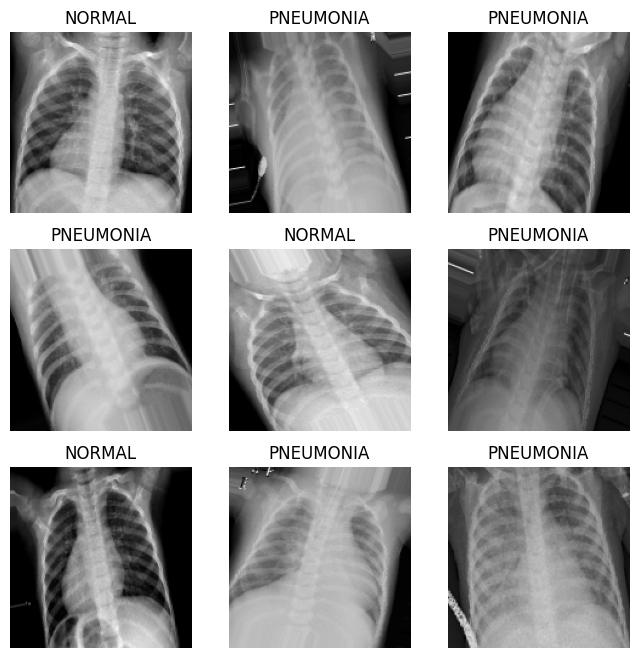

In [37]:
images, labels = next(train_data)

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])

    if labels[i] == 0:
        plt.title("NORMAL")
    else:
        plt.title("PNEUMONIA")

    plt.axis("off")

plt.show()

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 485ms/step - accuracy: 0.8043 - loss: 0.6405 - val_accuracy: 0.5000 - val_loss: 53.0515
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 486ms/step - accuracy: 0.8321 - loss: 0.3145 - val_accuracy: 0.5000 - val_loss: 26.3830
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 485ms/step - accuracy: 0.8562 - loss: 0.2619 - val_accuracy: 0.5000 - val_loss: 15.6072
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 475ms/step - accuracy: 0.8691 - loss: 0.2641 - val_accuracy: 0.6250 - val_loss: 6.6964
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 484ms/step - accuracy: 0.9001 - loss: 0.2299 - val_accuracy: 0.6250 - val_loss: 0.6930


In [41]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.8173 - loss: 0.4042
Test Loss: 0.4042060673236847
Test Accuracy: 0.817307710647583


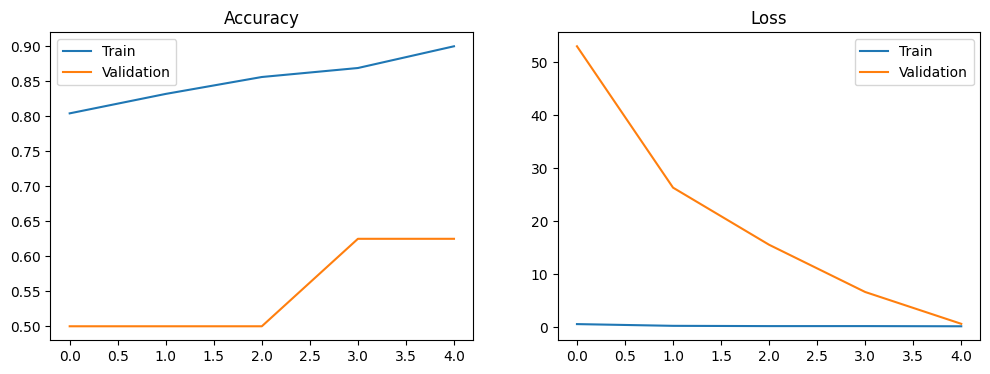

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step


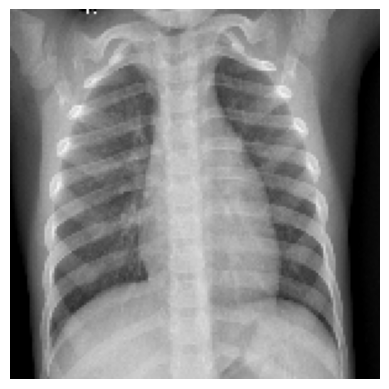

Actual    : NORMAL
Predicted : NORMAL


In [43]:
# Get one batch of test images
images, labels = next(test_data)

# Predict
predictions = model.predict(images)

# Display first image
plt.imshow(images[0])
plt.axis("off")
plt.show()

# Print actual and predicted labels
print("Actual    :", "PNEUMONIA" if labels[0] == 1 else "NORMAL")

if predictions[0] > 0.5:
    print("Predicted : PNEUMONIA")
else:
    print("Predicted : NORMAL")